Adapted from Deistler et al. (2025)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from math import pi

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
from sbi.inference import NPE
from torch import as_tensor, float32
from torch.distributions import Exponential, MultivariateNormal

/home/jakob/miniconda3/envs/sbi/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
plt.rcParams["svg.fonttype"] = "none"

In [4]:
def simulate(angle, strength, wind):
    xs = [0.0]
    ys = [0.0]

    angle = angle / 180 * pi

    dx = np.cos(angle) * strength
    dy = np.sqrt(strength**2 - dx**2)

    for i in range(10_000):
        x, y, dx, dy = step(xs[-1], ys[-1], dx, dy, dt, angle, strength, wind)
        xs.append(x)
        ys.append(y)
        if i > 1 and ys[-1] < 0:
            break
    return xs, ys


def step(x, y, dx, dy, dt, angle, strength, wind):
    gravity = 0.05
    friction_x = friction * dx
    friction_y = friction * dy

    ddy = -gravity - friction_y
    dy += ddy * dt

    ddx = wind - friction_x
    dx += ddx * dt

    return x + dx * dt, y + dy * dt, dx, dy


def throw_distance(xs, ys):
    frac = 1 - (ys[-1] / (ys[-1] - ys[-2]))
    return frac * (xs[-1] - xs[-2]) + xs[-2] + np.random.rand() * 0.1

In [5]:
angle = 45
strength = 0.7
friction = 0.01
dt = 0.5

In [6]:
all_xs = []
all_ys = []
dists = []

for wind in [0.0, 0.01, 0.03]:
    xs, ys = simulate(angle, strength, wind)
    all_xs.append(xs)
    all_ys.append(ys)
    dist = throw_distance(xs, ys)
    dists.append(dist)

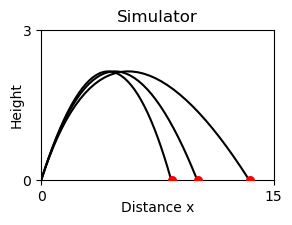

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(3*1.0, 3*0.65))
for xs, ys in zip(all_xs, all_ys):
    _ = ax.plot(xs, ys, c="k")
_ = ax.set_xlim([0, 15])
_ = ax.set_xticks([0, 15])
_ = ax.set_ylim([0, 3])
_ = ax.set_yticks([0, 3])
_ = ax.set_xlabel("Distance x", labelpad=-2)
_ = ax.set_ylabel("Height", labelpad=-1)
for dist in dists:
    _ = ax.scatter([dist], [0.0], s=30.0, c='red', zorder=1000)
plt.title('Simulator')
plt.show()

### Inference

In [8]:
prior_angle = MultivariateNormal(35 * torch.ones((1,)), 15**2 * torch.eye(1))
# prior_strength = Exponential(2.0 * torch.ones((1,)))
# prior_wind = MultivariateNormal(torch.zeros((1,)), 0.001 * torch.eye(1))
prior = prior_angle
latent = Exponential(200.0 * torch.ones((1,)))
# MultipleIndependent([
#    prior_angle,
# prior_strength,
# prior_wind,
# ])
friction = 0.1
dt = 0.5

In [9]:
num_sims = 10_000

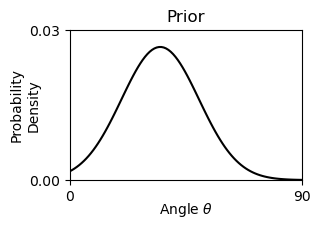

In [10]:
x_axis = torch.linspace(0, 90, 100).unsqueeze(1)
fig, ax = plt.subplots(1, 1, figsize=(3*1.0, 3*0.65))
_ = ax.plot(x_axis, prior.log_prob(x_axis).exp().numpy(), c="k")
_ = ax.set_xlim([0, 90])
_ = ax.set_xticks([0, 90])
_ = ax.set_ylim([0, 0.025])
_ = ax.set_yticks([0, 0.03])
_ = ax.set_xlabel("Angle " + r"$\theta$", labelpad=-2)
_ = ax.set_ylabel("Probability\nDensity", labelpad=-8)
plt.title('Prior')
plt.show()

# Train

In [11]:
theta = prior.sample((num_sims,))
z = latent.sample((num_sims,))
x = []
for t, zz in zip(theta, z):
    trace = simulate(t.item(), 2.0, zz.item())
    dist = throw_distance(*trace)
    x.append(dist)

x = torch.as_tensor(x, dtype=float32).unsqueeze(1)

In [12]:
_ = torch.manual_seed(0)
inference = NPE(prior=prior, density_estimator="nsf")
_ = inference.append_simulations(theta, x).train(max_num_epochs=200)

 Neural network successfully converged after 92 epochs.

In [13]:
posterior = inference.build_posterior()

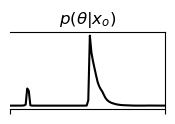

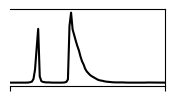

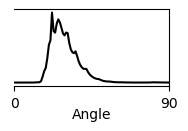

In [14]:
x_os = [13, 15, 16]
x_axis = torch.linspace(0, 90, 100)
for i, x_o_val in enumerate(x_os):
    x_o = as_tensor([[x_o_val]])
    #     samples = posterior.sample((100_000,), x=x_o)
    probs = torch.exp(posterior.log_prob(x_axis.unsqueeze(1), x=x_o))

    fig, ax = plt.subplots(1, 1, figsize=(2*1, 2*0.5))
    #         _ = ax.hist(samples.numpy(), range=[0, 90], bins=100, histtype="step", color="k")
    _ = ax.plot(x_axis, probs.numpy(), color="k")
    _ = ax.set_xlim([0, 90])
    _ = ax.set_xticks([0, 90])
    _ = ax.spines["left"].set_visible(False)
    _ = ax.set_yticks([])
    if i == len(x_os) - 1:
        _ = ax.set_xlabel("Angle", labelpad=-2)
    else:
        _ = ax.set_xticklabels([])

    if i == 0:
        ax.set_title(r"$p(\theta | x_o)$")
    plt.show()

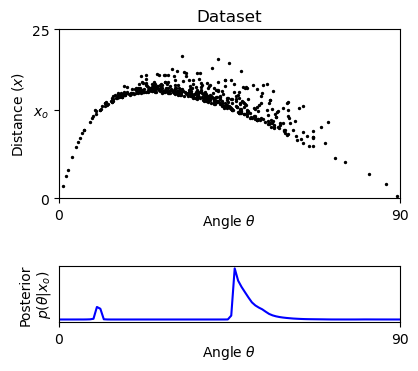

In [15]:
x_o_val = 13.0
x_axis = torch.linspace(0, 90, 100).unsqueeze(1)
probs = posterior.log_prob(x_axis, x=torch.as_tensor([[x_o_val]])).exp().numpy()

fig, ax = plt.subplots(
    2, 1, figsize=(2*2.2, 2*1.9), gridspec_kw={"height_ratios": [3, 1]}
)
_ = ax[0].scatter(theta[:500, 0].numpy(), x[:500, 0].numpy(), s=2.0, c="k")
# _ = ax[0].axhline(x_o_val, c='blue')

_ = ax[0].set_xticks([0, 90])
_ = ax[0].set_xlim([0, 90])
# _ = ax[0].set_xticklabels([])

_ = ax[0].set_yticks([0, x_o_val, 25])
_ = ax[0].set_yticklabels([0, r"$x_o$", 25])
_ = ax[0].set_ylim([0, 25])
_ = ax[0].set_xlabel("Angle " + r"$\theta$", labelpad=-7)

ax[0].set_title('Dataset')

# _ = ax.axhline(14.0)
_ = ax[1].plot(x_axis, 20 * probs + x_o_val, c='blue')
_ = ax[1].set_xticks([0, 90])
_ = ax[1].set_xlim([0, 90])
_ = ax[1].set_yticks([])
# _ = ax.axvline(70.0, c="r")

_ = ax[1].set_xlabel("Angle " + r"$\theta$", labelpad=-2)
_ = ax[0].set_ylabel("Distance " + r"$(x)$")
_ = ax[1].set_ylabel("Posterior\n" + r"$p(\theta | x_o)$")
plt.subplots_adjust(hspace=0.6)
plt.show()

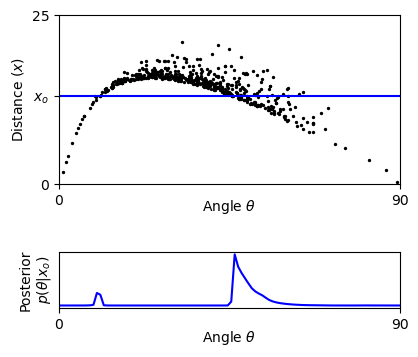

In [16]:
x_o_val = 13.0
x_axis = torch.linspace(0, 90, 100).unsqueeze(1)
probs = posterior.log_prob(x_axis, x=torch.as_tensor([[x_o_val]])).exp().numpy()

fig, ax = plt.subplots(
    2, 1, figsize=(2*2.2, 2*1.9), gridspec_kw={"height_ratios": [3, 1]}
)
_ = ax[0].scatter(theta[:500, 0].numpy(), x[:500, 0].numpy(), s=2.0, c="k")
_ = ax[0].axhline(x_o_val, c='blue')

_ = ax[0].set_xticks([0, 90])
_ = ax[0].set_xlim([0, 90])
# _ = ax[0].set_xticklabels([])

_ = ax[0].set_yticks([0, x_o_val, 25])
_ = ax[0].set_yticklabels([0, r"$x_o$", 25])
_ = ax[0].set_ylim([0, 25])
_ = ax[0].set_xlabel("Angle " + r"$\theta$", labelpad=-7)

# _ = ax.axhline(14.0)
_ = ax[1].plot(x_axis, 20 * probs + x_o_val, c='blue')
_ = ax[1].set_xticks([0, 90])
_ = ax[1].set_xlim([0, 90])
_ = ax[1].set_yticks([])
# _ = ax.axvline(70.0, c="r")

_ = ax[1].set_xlabel("Angle " + r"$\theta$", labelpad=-2)
_ = ax[0].set_ylabel("Distance " + r"$(x)$")
_ = ax[1].set_ylabel("Posterior\n" + r"$p(\theta | x_o)$")
plt.subplots_adjust(hspace=0.6)
plt.show()

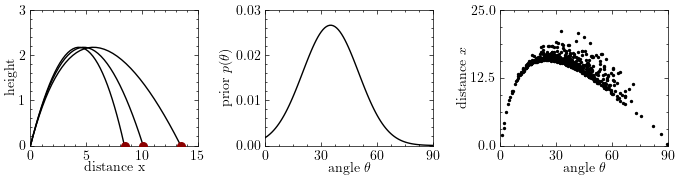

In [17]:
import scienceplots
plt.style.use('science')

x_axis = torch.linspace(0, 90, 100).unsqueeze(1)

fig, ax = plt.subplots(1, 3, figsize=(7, 2))
_ = ax[1].plot(x_axis, prior.log_prob(x_axis).exp().numpy(), c="k")
_ = ax[1].set_xlim([0, 90])
_ = ax[1].set_xticks([0,30,60,90])
_ = ax[1].set_ylim([0, 0.025])
_ = ax[1].set_yticks([0,0.01,0.02,0.03])
_ = ax[1].set_xlabel(r"angle $\theta$", labelpad=0)
_ = ax[1].set_ylabel(r"prior $p(\theta)$", labelpad=2)

for xs, ys in zip(all_xs, all_ys):
    _ = ax[0].plot(xs, ys, c="k")
_ = ax[0].set_xlim([0, 15])
_ = ax[0].set_xticks([0,5,10,15])
_ = ax[0].set_ylim([0, 3])
_ = ax[0].set_yticks([0,1,2,3])
_ = ax[0].set_xlabel("distance x", labelpad=0)
_ = ax[0].set_ylabel("height", labelpad=1)
for dist in dists:
    _ = ax[0].scatter([dist], [0.0], s=30.0, c='darkred', zorder=1000)

_ = ax[2].scatter(theta[:500, 0].numpy(), x[:500, 0].numpy(), s=2.0, c="k")
# _ = ax[0].axhline(x_o_val, c='blue')

_ = ax[2].set_xticks([0,30,60,90])
_ = ax[2].set_xlim([0, 90])
# _ = ax[0].set_xticklabels([])

_ = ax[2].set_yticks([0,12.5,25])
# _ = ax[1,0].set_yticklabels([0, r"$x_o$", 25])
_ = ax[2].set_ylim([0, 25])
_ = ax[2].set_xlabel(r"angle $\theta$", labelpad=0)
_ = ax[2].set_ylabel(r"distance $x$", labelpad=1)

plt.tight_layout(w_pad=1)
plt.savefig("fig_sbi-simulation.pdf")
plt.show()

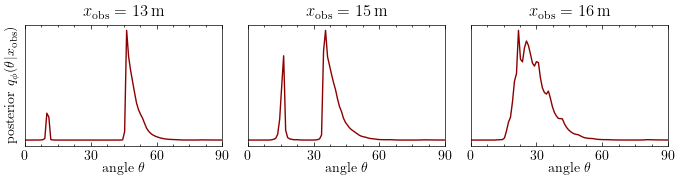

In [18]:
x_os = [13, 15, 16]
x_axis = torch.linspace(0, 90, 100)

fig, ax = plt.subplots(1, 3, figsize=(7, 2))

for i, x_o_val in enumerate(x_os):
    x_o = as_tensor([[x_o_val]])
    #     samples = posterior.sample((100_000,), x=x_o)
    probs = torch.exp(posterior.log_prob(x_axis.unsqueeze(1), x=x_o))

    _ = ax[i].plot(x_axis, probs.numpy(), color="darkred")
    _ = ax[i].set_xlim([0, 90])
    _ = ax[i].set_xticks([0,30,60,90])
    # _ = ax[i].spines["left"].set_visible(False)
    _ = ax[i].set_yticks([])
    _ = ax[i].set_xlabel(r"angle $\theta$", labelpad=0)
    if i == 0:
        _ = ax[i].set_ylabel(r"posterior $q_\phi(\theta|x_\text{obs})$", labelpad=4)
        _ = ax[i].set_title(r"$x_\text{obs} = 13\,\text{m}$")
    if i == 1:
        _ = ax[i].set_title(r"$x_\text{obs} = 15\,\text{m}$")
    if i == 2:
        _ = ax[i].set_title(r"$x_\text{obs} = 16\,\text{m}$")

plt.tight_layout()
plt.savefig("fig_sbi-est-posterior.pdf")
plt.show()